In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df




In [5]:
gamma = 0.9
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
Ts = [128]
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, .6, .7, .8, .9]
threshold = 1e-4
## Onehot Encoding
all_results = {eps: [] for eps in epsilons}
for epsilon in epsilons:
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        np.random.shuffle(irewards)
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]
   
            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0]
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

                cand_pe = position_encoder(df_all_paths.iloc[:,-1], type='onehot')
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM

                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])

                if np.random.rand() < epsilon:
                    candidates = get_candidates(current_state, gamma)
                    next_state = np.random.choice(candidates)

                    
                # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
                # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization = True)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            if T == 256:
                plt.plot(np.arange(T+1,T+101),future_states[1:])
                plt.plot(np.arange(T,T+101),path)
                plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        all_results[epsilon].append(FUTURE_STATE_arr)

128 train done
128 [np.float64(1.0), 2, 2, 3, 2, 3, 3, 3, 2, 2, 3, 3, 2, np.int64(2), 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, np.int64(1), 1, 2, 3, 3, 4, 5, np.int64(5), 5, 5, 5, 4, 3, 2, 1, 1, 1, 2, 2, 2, np.int64(2), np.int64(1), 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, np.int64(1), 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 3, 2, 2, 1, 2, np.int64(3), 2, 3, 4, 5, 4, 3, 2, 2, 2, 3, 2, 2, 2, 2, 3, np.int64(3), 2, 2, 2, 1] 101
2.2192429834513323
128 train done
128 [np.float64(1.0), 2, 2, 3, 2, 3, 3, np.int64(4), 3, 2, np.int64(3), np.int64(3), 2, np.int64(3), 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, np.int64(1), np.int64(1), 2, 3, 2, 3, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 2, np.int64(2), np.int64(1), 2, 3, 2, 2, 2, 3, 2, 3, np.int64(2), np.int64(3), 2, 2, np.int64(3), np.int64(2), 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 3, np.int64(4), 3, 2, 2, np.int64(3), 2, 3, 4, np.int64(5), 4, 3, 2, 2, 2, 3, np.int64(3), 2, 2, 2, 3, 2, 2, np.int64(2), 2, np.int64(3)] 101
2.22660721470724
128 train done
128 [np

128 train done
128 [np.float64(1.0), np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, np.int64(0), np.int64(0), 1, 1, 1, 1, 1, 1, np.int64(1), 2, np.int64(1), 2, 3, 4, 5, 5, np.int64(6), 5, 4, 3, np.int64(4), 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, np.int64(2), 1, 1, 1, 1, np.int64(2), np.int64(1), 1, 1, 1, 2, 3, np.int64(3), 4, 5, 5, 5, 5, 5, 5, 5, np.int64(5), 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, np.int64(1), 1, 1, 1, 1, 2, 3, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
1.1648793535261355
256 train done
256 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 1, np.int64(0), np.int64(1), 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, np.int64(0), 1, 1, 2, 3, 4, 5, np.int64(5), 5, 5, 5, 5, 4, 3, 2, 1, 1, np.int64(2), 1, np.int64(2), 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, np.int64(4), np.int64(3), 2, 1, 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, np.int64(4), 5, 5, np.int64(6), 5, 5] 101
0.2993305210884557


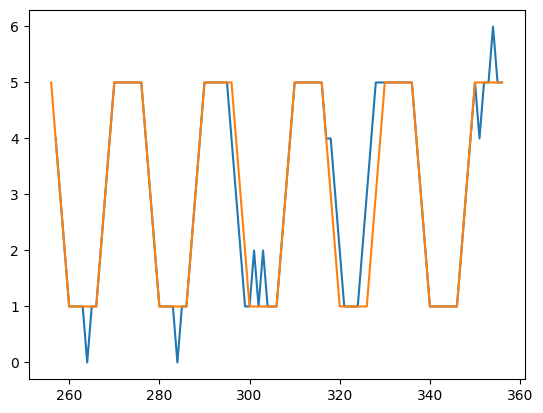

512 train done
512 [np.float64(4.0), 5, 5, 5, np.int64(5), 4, 3, 2, 1, np.int64(1), 1, 1, 1, 1, 1, 2, 3, np.int64(4), 5, 5, 5, 5, 5, 5, 5, np.int64(4), 3, 2, 1, 1, 1, 1, np.int64(0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, np.int64(4), 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, np.int64(4), 3, np.int64(2), 1, 1, 1, 1, 1, 1, np.int64(2), 3, 4, 5, np.int64(4), 5] 101
0.2904371571562322
750 train done
750 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, np.int64(2), 1, 1, 1, 1, 1, np.int64(2), 3, np.int64(3), 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, np.int64(5), np.int64(6), 5, 5, 5, 4, 3, 2, np.int64(3), 2, 1, 1, 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, np.int64(4), 3, 2, 1, 1, 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.5015412155834287
1024 train done
1024 [np.float64(2.0), 1, 1, 2, 3, 4, 5, 5, 5, np.int64(6), 5, 5

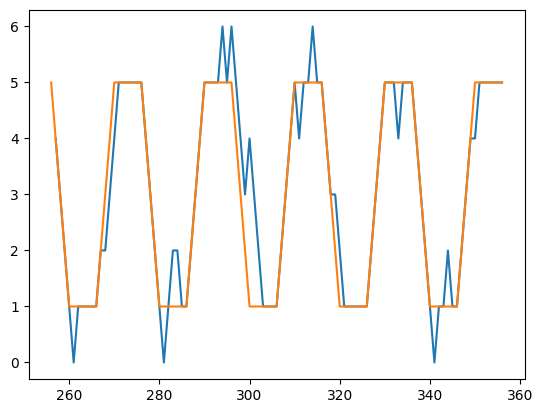

512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 4, 3, np.int64(4), 3, 2, 1, np.int64(0), 1, np.int64(2), np.int64(1), 2, 3, 4, 5, 5, 5, np.int64(4), 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, np.int64(0), 1, 2, 3, 4, 5, 5, 5, 5, np.int64(6), 5, np.int64(6), 5, np.int64(6), 5, 4, 3, np.int64(4), 3, 2, 1, 1, 2, np.int64(1), 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, np.int64(1), 1, np.int64(0), 1, 2, 3, 4, 5, 5, np.int64(6), 5, 5, 4, np.int64(3), 2, 1, 1, 1, 1, np.int64(0), 1, 1, 2, 3, 4, 5, 5, 5] 101
0.8046695378436675
750 train done
750 [np.float64(3.0), 4, 5, 5, np.int64(6), 5, np.int64(5), np.int64(4), 3, 2, 1, 1, 1, 1, 1, np.int64(0), 1, np.int64(0), 1, 2, 3, 4, 5, 5, 5, 5, np.int64(5), 4, np.int64(5), 4, 3, 2, 1, 1, 1, np.int64(2), 1, 2, 3, 4, 5, 5, np.int64(6), 5, 5, 5, 5, 4, np.int64(4), 3, np.int64(2), 1, 1, np.int64(2), 1, 1, 1, 2, 3, 4, 5, np.int64(6), 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, np.int64(2), 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, np.int64(1), 1, 1, 1, 1, 2, 3,

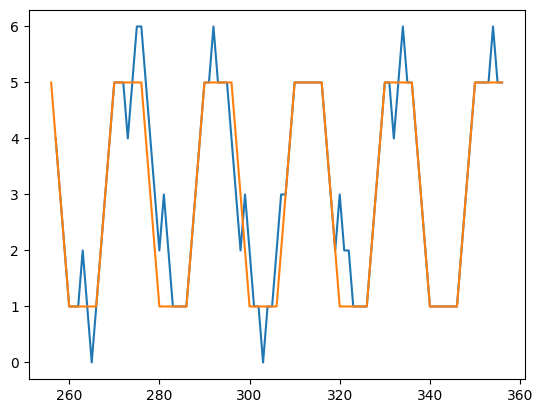

512 train done
512 [np.float64(4.0), 5, np.int64(4), 5, 5, np.int64(4), 3, 2, 1, 1, 1, 1, np.int64(0), 1, 1, 2, np.int64(1), 2, 3, 4, np.int64(4), 5, 5, 5, np.int64(4), 3, 2, 1, np.int64(0), np.int64(1), np.int64(2), 1, np.int64(1), 1, 1, 2, 3, 4, 5, np.int64(6), 5, 5, 5, 5, 5, np.int64(4), 3, 2, 1, 1, 1, 1, 1, 1, np.int64(0), np.int64(1), np.int64(0), 1, 2, np.int64(2), 3, 4, 5, np.int64(4), 5, np.int64(5), 4, 3, np.int64(4), 3, 2, 1, np.int64(0), 1, 1, 2, 3, 4, np.int64(3), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, np.int64(2), 1, np.int64(1), np.int64(0), 1, 2, 3, np.int64(4), np.int64(3), 4, np.int64(3)] 101
1.2906109863227513
750 train done
750 [np.float64(3.0), 4, np.int64(3), 4, 5, 5, np.int64(6), np.int64(5), 4, 3, np.int64(3), 2, np.int64(3), 2, 1, 1, 1, 2, 3, np.int64(4), 5, 5, 5, 5, 5, 5, np.int64(6), 5, 4, np.int64(4), 3, 2, 1, np.int64(2), 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, np.int64(6), 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, np.int64(2), 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 

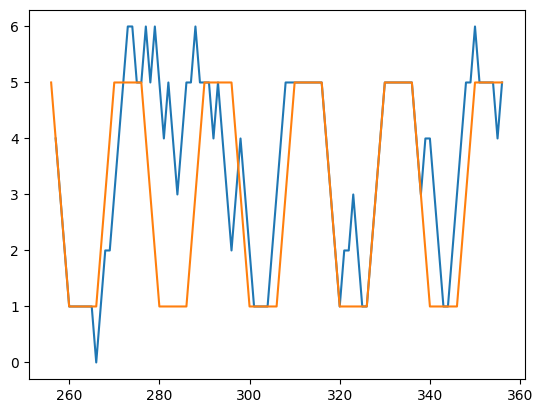

512 train done
512 [np.float64(4.0), np.float64(4.0), np.float64(4.0), np.float64(3.0), np.float64(2.0), 1, 1, 1, np.int64(0), np.int64(1), np.int64(2), 1, np.int64(1), 1, 1, 2, 3, 4, 5, np.int64(6), 5, 5, np.int64(4), 5, np.int64(4), 3, 2, 1, 1, 1, 1, 1, 1, np.int64(0), np.int64(1), np.int64(0), 1, np.int64(0), 0, 1, np.int64(2), 3, np.int64(2), np.int64(2), np.int64(3), 2, np.int64(3), np.int64(2), np.int64(1), 1, 1, 1, 1, 1, np.int64(0), np.int64(0), 1, np.int64(2), np.int64(2), 3, 4, 5, 5, 5, np.int64(4), 3, 2, np.int64(1), np.int64(1), 1, 1, np.int64(2), np.int64(1), 1, np.int64(0), 1, np.int64(0), 1, 2, 3, np.int64(4), np.int64(3), 4, np.int64(4), np.int64(4), 3, 2, 1, 1, 1, np.int64(1), 1, 1, 1, 1, 2, 3, 4, 5, np.int64(6), 5] 101
1.020181361184635
750 train done
750 [np.float64(3.0), 4, np.int64(4), 5, np.int64(5), np.int64(6), 5, 4, 3, np.int64(4), 3, 2, 1, 1, 1, 1, np.int64(1), np.int64(2), 3, 4, 5, 5, 5, np.int64(4), 5, 5, 5, np.int64(5), 4, np.int64(5), 4, 3, np.int64(3), 2,

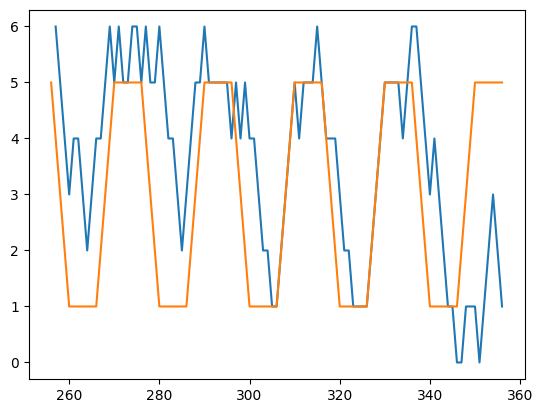

512 train done
512 [np.float64(4.0), np.float64(3.0), np.float64(4.0), 5, np.int64(5), 4, np.int64(5), 4, np.int64(3), 2, np.int64(3), 2, 1, np.int64(0), 1, np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), 2, 3, np.int64(2), 1, 1, 2, 2, np.int64(2), np.int64(2), np.int64(3), 2, np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(2), 3, 4, np.int64(3), 4, 5, 5, 5, 5, np.int64(4), np.int64(4), 3, np.int64(4), np.int64(4), 3, np.int64(3), 2, 1, 1, np.int64(2), 3, np.int64(3), np.int64(2), np.int64(3), 4, 5, 5, np.int64(4), np.int64(3), np.int64(4), 3, 2, 1, 1, 1, np.int64(2), np.int64(1), 1, np.int64(1), np.int64(1), 2, 3, 4, 5, 5, np.int64(5), 5, 5, np.int64(4), 5, 4, np.int64(4), np.int64(4), 3, np.int64(4), 3, np.int64(2), np.int64(2), np.int64(3), 4, 5, 5, np.int64(6), np.int64(6), 5, 5] 101
1.647443024026261
750 train done
750 [np.float64(3.0), 4, np.int64(3), np.int64(3), np.int64(4), np.int64(3), 2, 1, 1, 1, 1, 1, 1, 1, np.int64(1), 1, np.int64(2), 3, 4, np

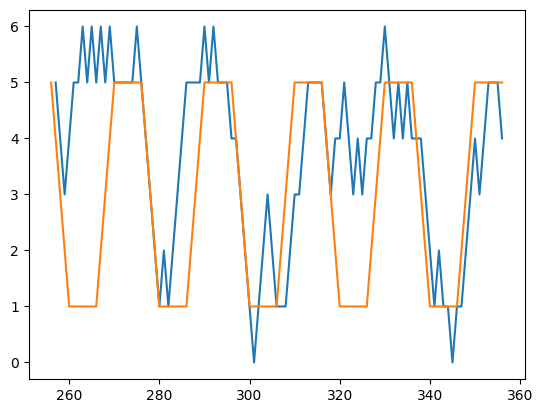

512 train done
512 [np.float64(4.0), 5, np.int64(4), np.int64(5), np.int64(4), np.int64(3), np.int64(3), 2, 1, np.int64(0), 1, 1, 1, 1, np.int64(1), np.int64(1), np.int64(2), 3, np.int64(2), np.int64(2), np.int64(3), np.int64(4), np.int64(3), 4, np.int64(3), np.int64(2), 2, 1, 1, np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), 4, np.int64(4), 3, 4, 5, np.int64(6), 5, np.int64(5), np.int64(4), np.int64(5), 5, 4, 3, np.int64(2), np.int64(1), np.int64(2), np.int64(1), 1, 1, 1, np.int64(2), np.int64(1), 2, np.int64(2), np.int64(2), np.int64(1), 2, 3, np.int64(4), np.int64(4), 5, np.int64(4), 3, 2, 1, np.int64(1), np.int64(1), 1, np.int64(2), 1, np.int64(0), np.int64(0), 1, 2, 3, 4, 5, np.int64(6), np.int64(6), 5, 5, 4, np.int64(3), np.int64(3), np.int64(4), np.int64(3), 2, 1, np.int64(2), np.int64(1), 1, 2, 3, np.int64(3), 4, np.int64(5), 5] 101
1.3555504787006396
750 train done
750 [np.float64(3.0), 4, np.int64(4), np.int64(3), np.int64(2), np.int64(1), np.int64(1), np.in

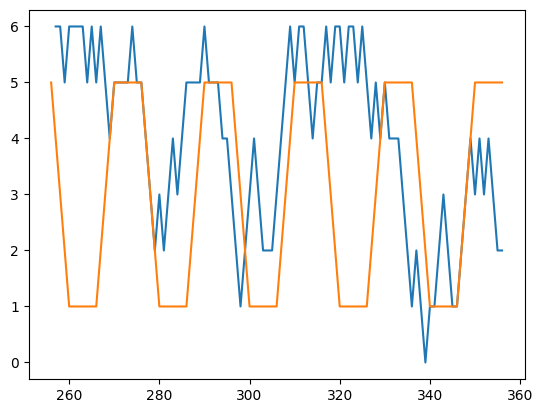

512 train done
512 [np.float64(4.0), np.float64(4.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), 1, np.int64(0), 1, np.int64(1), 1, np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(2), 3, np.int64(2), np.int64(1), 2, 3, 4, np.int64(5), np.int64(5), np.int64(5), np.int64(6), np.int64(6), 5, np.int64(4), 3, np.int64(3), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), 1, 1, 1, np.int64(2), np.int64(1), 1, np.int64(1), np.int64(1), np.int64(0), 1, 1, np.int64(2), np.int64(2), np.int64(1), np.int64(0), 1, np.int64(1), np.int64(1), np.int64(2), np.int64(3), 4, np.int64(3), np.int64(3), np.int64(4), 3, 2, 1, np.int64(2), np.int64(2), 1, 1, 1, np.int64(0), np.int64(0), np.int64(1), np.int64(0), 1, np.int64(2), np.int64(1), 2, 2, 3, np.int64(3), 2, np.int64(3), 2, np.int64(3), np.int64(4), 3, np.int64(2), np.int64(1), np.int64(1), np.int64(2), 1, np.int64(1), np.int64(0), np.int64(

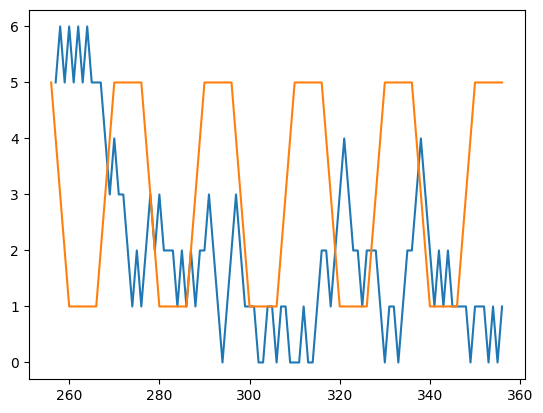

512 train done
512 [np.float64(4.0), np.float64(3.0), 4, np.int64(4), np.int64(5), np.int64(4), np.int64(5), 4, 3, np.int64(4), 3, np.int64(2), np.int64(1), np.int64(0), 1, 2, 3, np.int64(4), np.int64(3), np.int64(2), 3, np.int64(4), np.int64(5), 5, np.int64(6), np.int64(6), 5, np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(4), np.int64(4), np.int64(3), np.int64(4), np.int64(3), 4, 5, np.int64(4), 5, np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(4), 3, np.int64(2), np.int64(2), np.int64(1), np.int64(0), 1, np.int64(1), np.int64(1), np.int64(2), np.int64(3), 4, np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(5), np.int64(5), np.int64(4), np.int64(3), np.int64(2), np.int64(2), np.int64(3), np.int64(2), 1, np.int64(2), np.int64(1), 1, np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(3), 4, np.int64(3), np.int64(2), np.int64(2), np.int64(3), 2, np.int64(2), np.int64(1), np.int64(0), np.int64(1), np

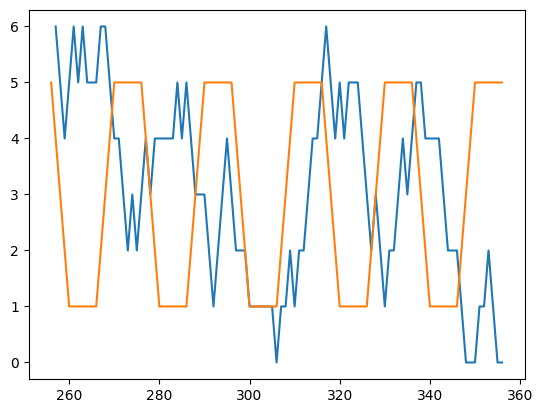

512 train done
512 [np.float64(4.0), np.float64(5.0), np.float64(4.0), np.float64(5.0), np.float64(4.0), np.float64(3.0), 2, 1, np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(3), np.int64(4), np.int64(4), 5, np.int64(5), 6, np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), 5, np.int64(6), np.int64(5), np.int64(5), np.int64(4), np.int64(5), np.int64(4), 3, 2, np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), 0, np.int64(0), 0, np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), 1, np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(2), np.int64(1), 0, np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), 1, np.int64(0), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(2), 3, np.int64(2), np.int64(1), np.int64(2), np.int6

In [6]:
gamma = 0.9
Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]

threshold = 1e-4
## Onehot Encoding
for epsilon in epsilons:
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = 515)
        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
            X_train_oh = new_state_oh[:T,:]
            Y_train_value = prewards[:T]
            Y_train_action = irewards[:T]

            rf_value = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_value.fit(X_train_oh, Y_train_value)

            
            rf_action = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact", 
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse")
            rf_action.fit(X_train_oh, Y_train_action)

            print(T,'train done')
            current_state = states[T,0]
            # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = rf_action.predict(features)
                # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

                cand_pe = position_encoder(df_all_paths.iloc[:,-1], type='onehot')
                curr_time = T+1+delta_t+t_prime+1
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                
                prewards_pred = rf_value.predict(features)
                df_ireward[f"preward"] = prewards_pred
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(0, t_prime+1)

                discounted_returns = rewards_matrix * discounts # PVAFM

                total_discounted = discounted_returns.sum(axis=1)
                # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                if np.random.rand() < epsilon:
                    candidates = get_candidates(current_state, gamma)
                    next_state = np.random.choice(candidates)

                future_states.append(next_state)
                current_state = next_state
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5,normalization = True)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5,normalization = True)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            if T == 256:
                plt.plot(np.arange(T+1,T+101),future_states[1:])
                plt.plot(np.arange(T,T+101),path)
                plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        all_results[epsilon].append(FUTURE_STATE_arr)


In [7]:
save_dict = {}
for eps in epsilons:
    save_dict[f"eps_{eps}"] = np.vstack(all_results[eps])
np.savez(
    "../results/PVAFM/stochastic_gbt_gamma0.9.npz",
    **save_dict
)